<a href="https://colab.research.google.com/github/merasifa/PCVK/blob/main/WEEK6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Pengolahan Citra Digital - Week 6

**Nama:** Tiara Mera Sifa <br>
**NIM:** 2141720247 <br>
**Kelas:** TI-3B <br>


In [5]:

from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Import beberapa library berikut yang akan digunakan selama uji coba praktikum
minggu ke-6 berikut.

In [6]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import math
import numpy as np
import os
import glob

Buatlah histogram citra seperti output histogram berikut berdasarkan flowchart di
bawah ini : (Gunakan gambar lena.jpg)

<BarContainer object of 256 artists>

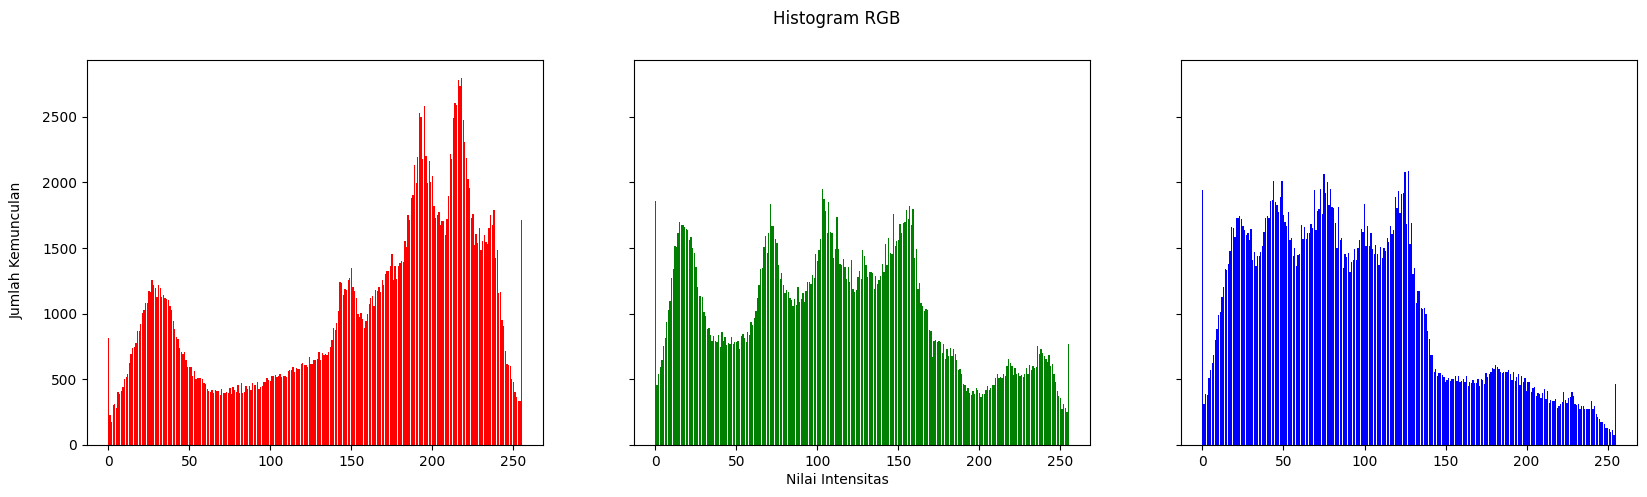

In [7]:
img = cv.imread('/content/gdrive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', ha='center', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Nilai Intensitas', ha='center', va='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')


Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan
hasilnya. Apakah output muncul sama?

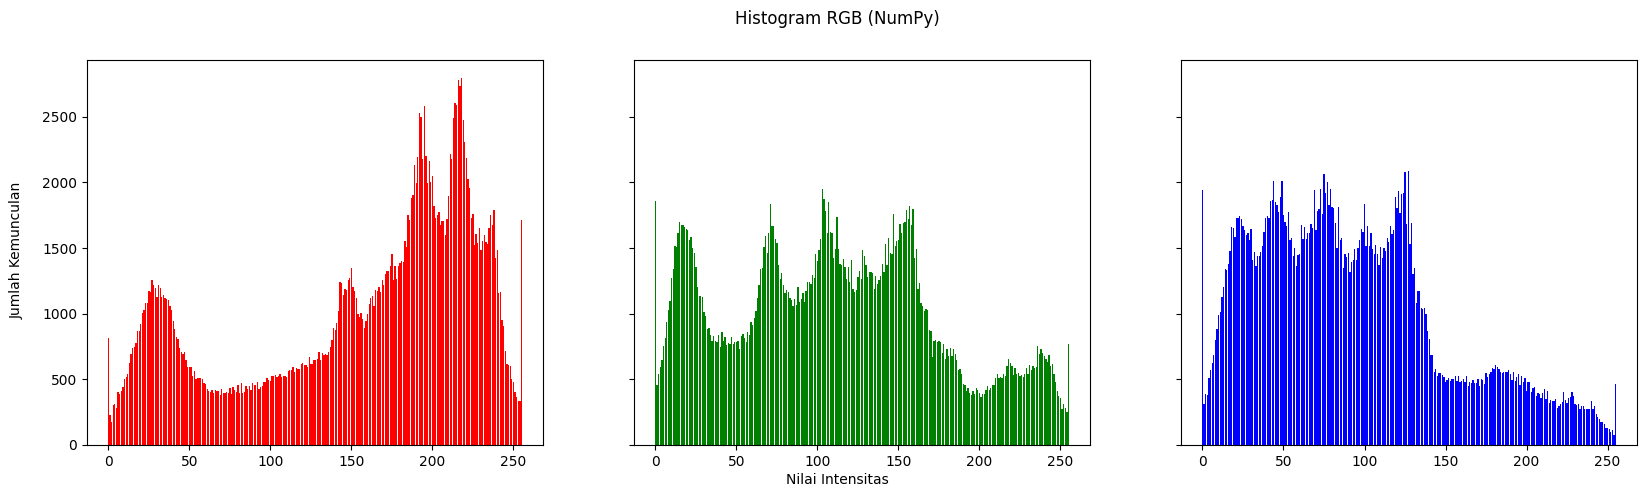

In [8]:
hist_red, bins_red = np.histogram(img[:, :, 0], bins=256, range=(0, 256))
hist_green, bins_green = np.histogram(img[:, :, 1], bins=256, range=(0, 256))
hist_blue, bins_blue = np.histogram(img[:, :, 2], bins=256, range=(0, 256))

fig2, axs2 = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig2.suptitle('Histogram RGB (NumPy)')
fig2.text(0.09, 0.5, 'Jumlah Kemunculan', ha='center', va='center', rotation='vertical')
fig2.text(0.5, 0.04, 'Nilai Intensitas', ha='center', va='center')
axs2[0].bar(names, hist_red, color='red')
axs2[1].bar(names, hist_green, color='green')
axs2[2].bar(names, hist_blue, color='blue')
plt.show()

Buatlah histogram citra seperti output histogram equalization dan juga tampilan
gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan
flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

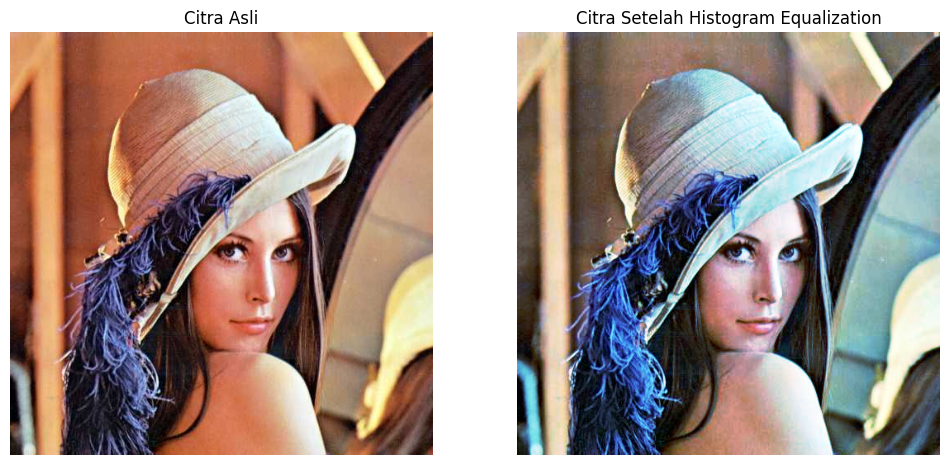

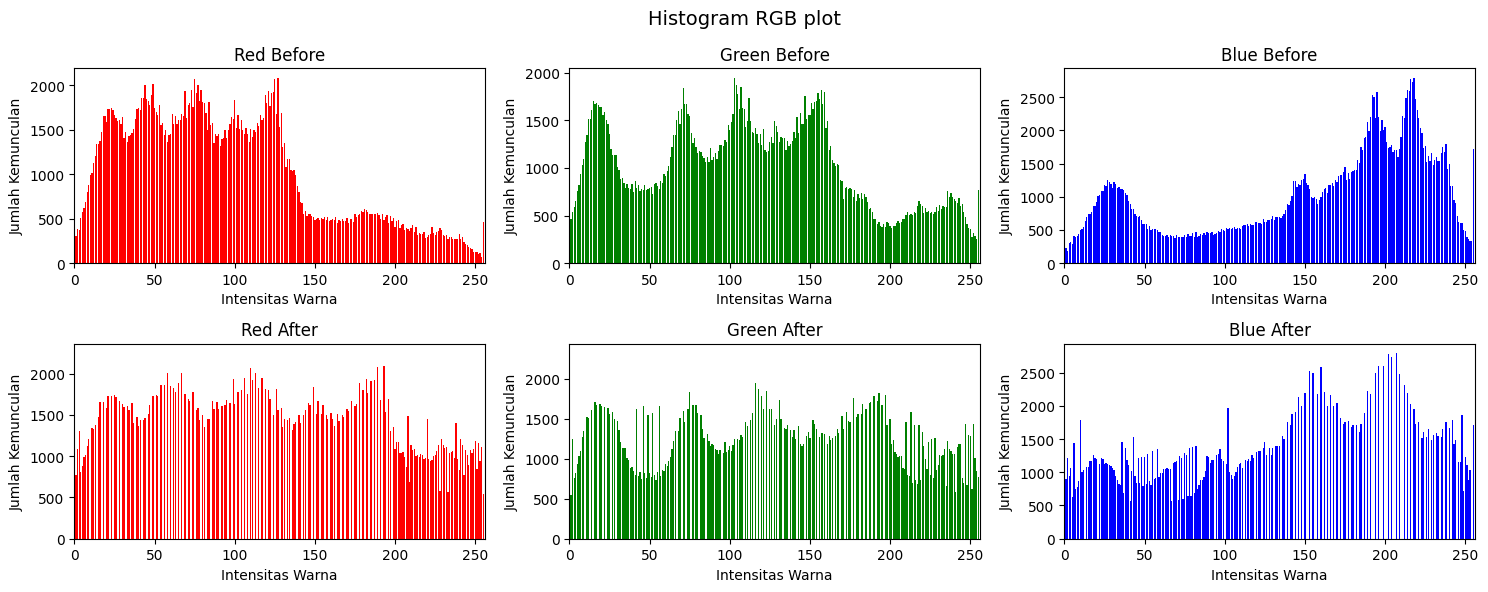

In [16]:
# Baca gambar
img = cv.imread('/content/gdrive/MyDrive/PCVK/Images/lena.jpg')

# --- Split channel ---
b, g, r = cv.split(img)

# --- Histogram Equalization tiap channel ---
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

# --- Gabungkan kembali ---
img_eq = cv.merge((b_eq, g_eq, r_eq))

# --- Tampilkan citra sebelum & sesudah ---
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(img_eq, cv.COLOR_BGR2RGB))
plt.title("Citra Setelah Histogram Equalization")
plt.axis("off")
plt.show()

# --- Histogram RGB sebelum & sesudah ---
colors = ('r','g','b')
channel_names = ('Red','Green','Blue')

fig, axs = plt.subplots(2,3, figsize=(15,6))
fig.suptitle("Histogram RGB plot", fontsize=14)

for i, col in enumerate(colors):
    # Before
    hist_before = cv.calcHist([img],[i],None,[256],[0,256])
    axs[0,i].bar(np.arange(256), hist_before.ravel(), color=col)
    axs[0,i].set_title(f"{channel_names[i]} Before")
    axs[0,i].set_xlim([0,256])
    axs[0,i].set_xlabel("Intensitas Warna")
    axs[0,i].set_ylabel("Jumlah Kemunculan")

    # After
    hist_after = cv.calcHist([img_eq],[i],None,[256],[0,256])
    axs[1,i].bar(np.arange(256), hist_after.ravel(), color=col)
    axs[1,i].set_title(f"{channel_names[i]} After")
    axs[1,i].set_xlim([0,256])
    axs[1,i].set_xlabel("Intensitas Warna")
    axs[1,i].set_ylabel("Jumlah Kemunculan")

plt.tight_layout()
plt.show()

Setelah mengerjakan soal no. 5, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”. Bandingkan
hasilnya. Apakah output muncul sama?

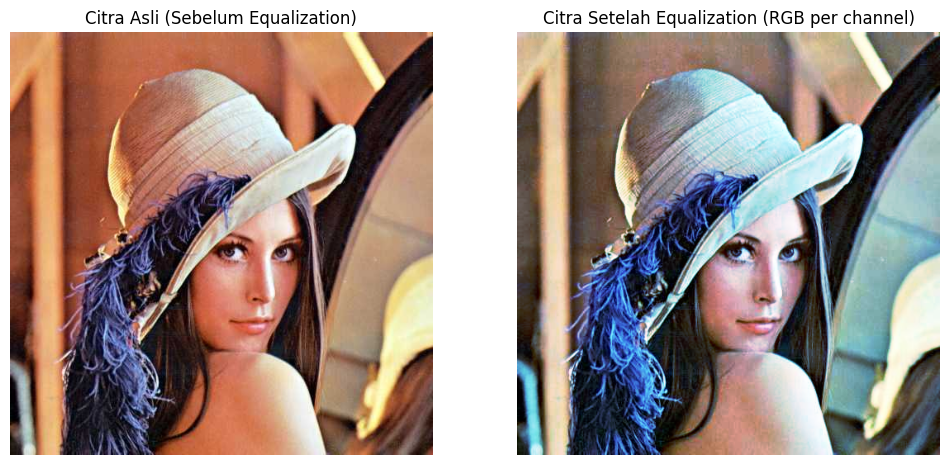

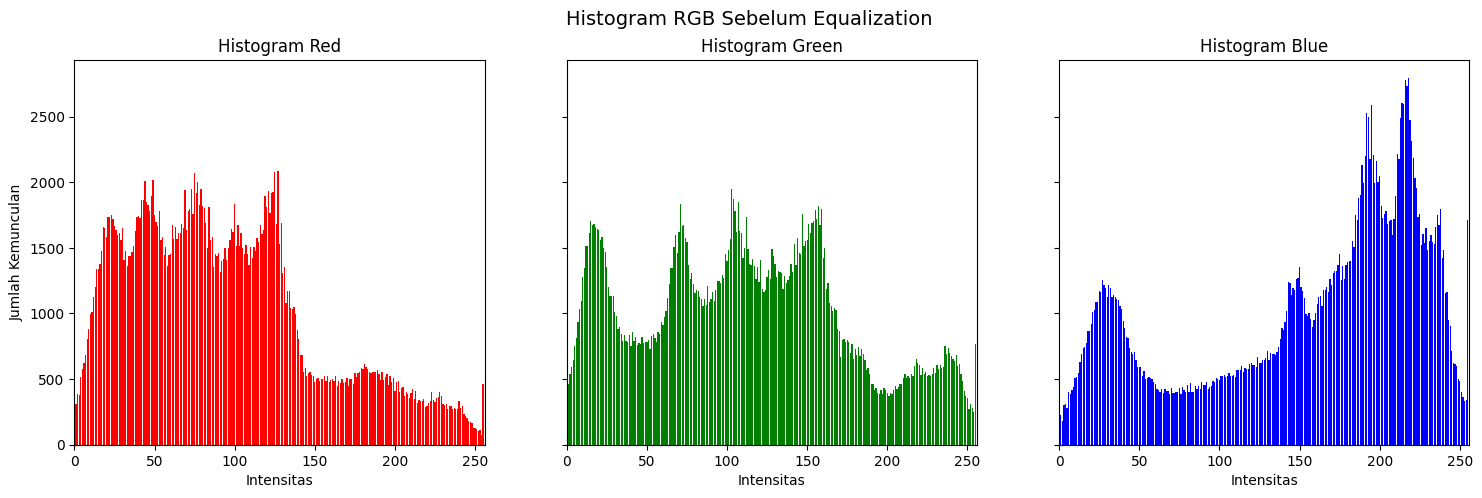

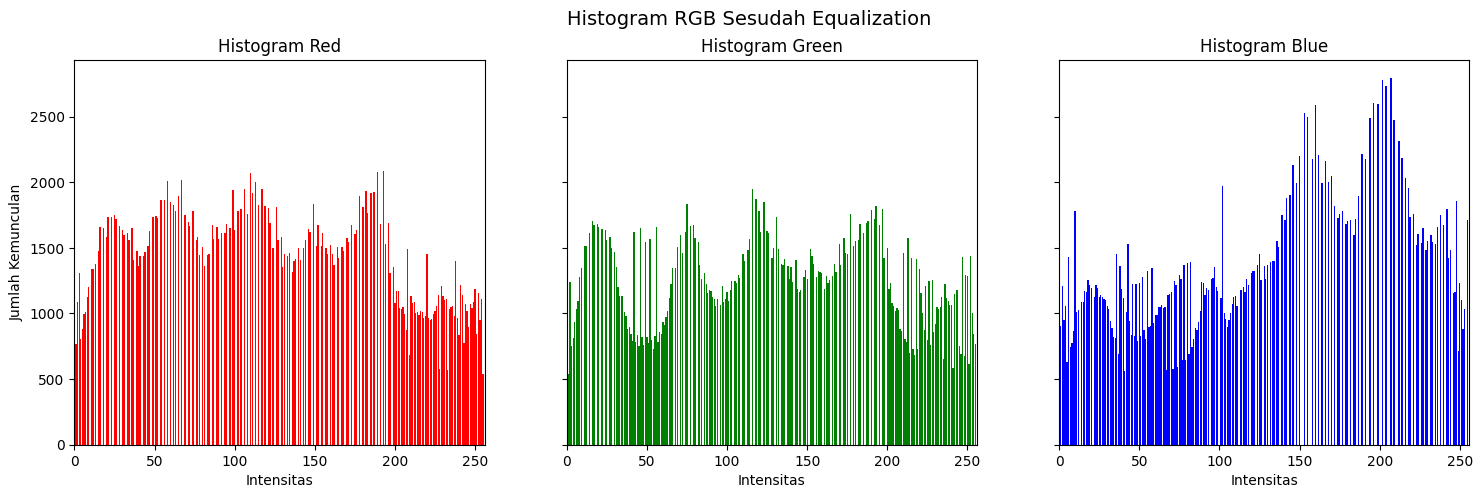

In [17]:
# Baca gambar
img = cv.imread('/content/gdrive/MyDrive/PCVK/Images/lena.jpg')

# Split ke R, G, B
B, G, R = cv.split(img)

# Histogram Equalization masing-masing channel
R_eq = cv.equalizeHist(R)
G_eq = cv.equalizeHist(G)
B_eq = cv.equalizeHist(B)

# Gabungkan kembali
img_eq = cv.merge((B_eq, G_eq, R_eq))

# Fungsi untuk menampilkan histogram per channel
def plot_histogram_subplot(img, title):
    channels = cv.split(img)
    colors = ('r', 'g', 'b')
    channel_names = ('Red', 'Green', 'Blue')
    fig, axs = plt.subplots(1, 3, figsize=(18,5), sharey=True)
    fig.suptitle(title, fontsize=14)

    for i, (ch, col) in enumerate(zip(channels, colors)):
        hist = cv.calcHist([ch],[0],None,[256],[0,256])
        axs[i].bar(np.arange(256), hist.ravel(), color=col)
        axs[i].set_title(f'Histogram {channel_names[i]}')
        axs[i].set_xlim([0,256])
        axs[i].set_xlabel("Intensitas")
        if i == 0:
            axs[i].set_ylabel("Jumlah Kemunculan")

    plt.show()

# Tampilkan gambar sebelum dan sesudah
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Citra Asli (Sebelum Equalization)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(img_eq, cv.COLOR_BGR2RGB))
plt.title("Citra Setelah Equalization (RGB per channel)")
plt.axis("off")
plt.show()

# Histogram sebelum dan sesudah
plot_histogram_subplot(img, "Histogram RGB Sebelum Equalization")
plot_histogram_subplot(img_eq, "Histogram RGB Sesudah Equalization")


Lakukanlah proses pemetaan 16 juta warna RGB ke dalam 8 warna saja, yaitu hitam,
hijau, kuning, biru, cyan, magenta, putih seperti output berikut berdasarkan flowchart
di bawah ini! (Gunakan gambar lena.jpg)


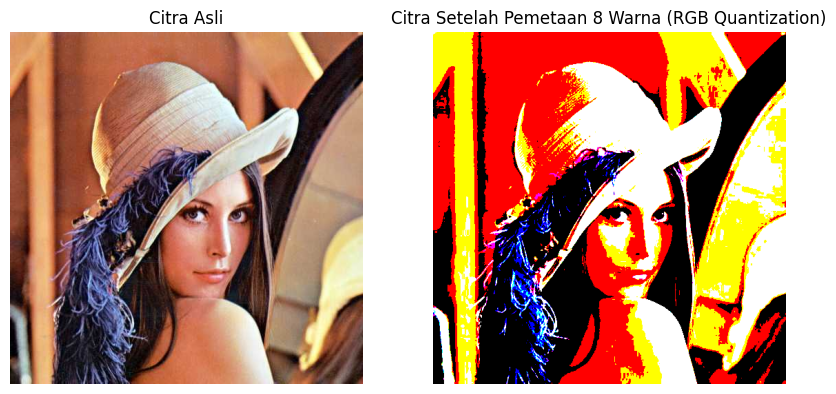

In [35]:
img = cv2.imread('/content/gdrive/MyDrive/PCVK/Images/lena.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# --- Pemetaan RGB 16 juta warna menjadi 8 warna ---

# Threshold setiap channel menjadi 0 atau 255
r = np.where(img[:,:,0] >= 128, 255, 0)
g = np.where(img[:,:,1] >= 128, 255, 0)
b = np.where(img[:,:,2] >= 128, 255, 0)

# Gabungkan channel hasil threshold
quantized_img = np.stack([r,g,b], axis=2).astype(np.uint8)

# === End ===

# Tampilkan hasil
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(quantized_img)
plt.title('Citra Setelah Pemetaan 8 Warna (RGB Quantization)')
plt.axis('off')

plt.show()


Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image
awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

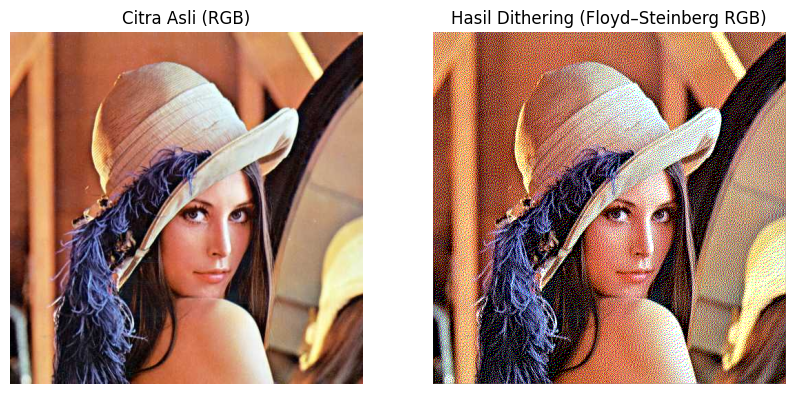

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Fungsi Floyd-Steinberg Dithering untuk gambar berwarna
def floyd_steinberg_dithering_color(img):
    h, w, c = img.shape
    out = img.copy().astype(np.float32)

    for y in range(h - 1):
        for x in range(1, w - 1):
            for channel in range(c):  # proses setiap channel (R, G, B)
                old_pixel = out[y, x, channel]
                new_pixel = 255 if old_pixel > 127 else 0
                out[y, x, channel] = new_pixel
                error = old_pixel - new_pixel

                # Sebarkan error ke piksel tetangga (kernel Floyd–Steinberg)
                out[y, x+1, channel]   += error * 7/16
                out[y+1, x-1, channel] += error * 3/16
                out[y+1, x, channel]   += error * 5/16
                out[y+1, x+1, channel] += error * 1/16

    # Pastikan nilai dalam rentang [0, 255]
    out = np.clip(out, 0, 255)
    return out.astype(np.uint8)

# Baca gambar dan ubah ke RGB
img = cv.imread('/content/gdrive/MyDrive/PCVK/Images/lena.jpg')
img_lena = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Terapkan dithering
dither_lena = floyd_steinberg_dithering_color(img_lena)

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_lena)
plt.title("Citra Asli (RGB)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dither_lena)
plt.title("Hasil Dithering (Floyd–Steinberg RGB)")
plt.axis("off")
plt.show()


Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!

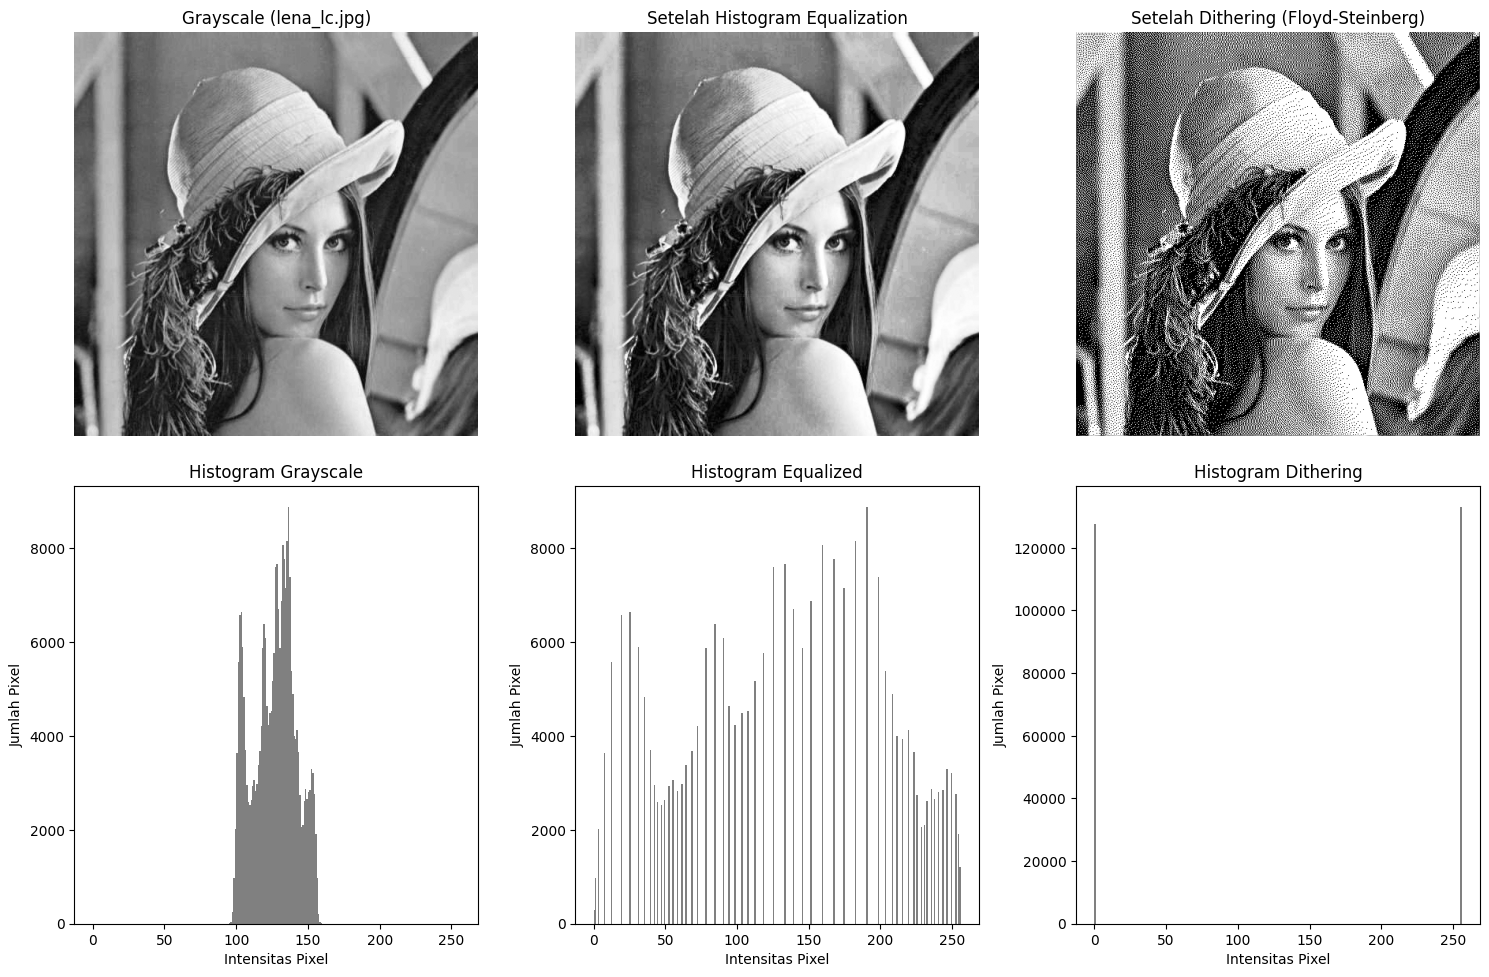

In [36]:
def floyd_steinberg_dithering(img):
    h, w = img.shape
    out = img.copy().astype(np.float32)
    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = out[y, x]
            new_pixel = 255 if old_pixel > 127 else 0
            out[y, x] = new_pixel
            error = old_pixel - new_pixel
            out[y, x+1]   += error * 7/16
            out[y+1, x-1] += error * 3/16
            out[y+1, x]   += error * 5/16
            out[y+1, x+1] += error * 1/16
    out = np.clip(out, 0, 255)
    return out.astype(np.uint8)

img = cv.imread('/content/gdrive/MyDrive/PCVK/Images/lena_lc.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
equalized = cv.equalizeHist(gray)
dithered = floyd_steinberg_dithering(equalized)

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale (lena_lc.jpg)")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(equalized, cmap="gray")
plt.title("Setelah Histogram Equalization")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(dithered, cmap="gray")
plt.title("Setelah Dithering (Floyd-Steinberg)")
plt.axis("off")

plt.subplot(2,3,4)
plt.hist(gray.ravel(), bins=256, range=(0,256), color="grey")
plt.title("Histogram Grayscale")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")

plt.subplot(2,3,5)
plt.hist(equalized.ravel(), bins=256, range=(0,256), color="grey")
plt.title("Histogram Equalized")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")

plt.subplot(2,3,6)
plt.hist(dithered.ravel(), bins=256, range=(0,256), color="grey")
plt.title("Histogram Dithering")
plt.xlabel("Intensitas Pixel")
plt.ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()